# PySpark: de un CSV a un pipeline distribuido

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** IA & Big Data · Big Data Distribuido · Procesamiento con PySpark

---

## Objetivo

Recorrer el ciclo completo de trabajo con **Apache Spark** sobre un dataset de ventas de **203.533 registros**: desde la lectura tipada del CSV hasta un pipeline de MLlib, pasando por SQL distribuido, funciones de ventana, joins, gestión de particiones y caché, y escritura en formato columnar.

No es un recorrido por la API: cada sección responde a una pregunta que se resuelve distinto en Spark que en pandas, y varias terminan en un **coste real medido**, no en una recomendación teórica.

## Contexto de negocio

**El cliente:** una cadena de retail tecnológico con presencia en 8 ciudades españolas.

**El problema:** el histórico de ventas (2022–2024) ha crecido hasta un volumen en el que los análisis mensuales en Excel y pandas empiezan a tardar más que la reunión en la que se presentan. Antes de mover el proceso a un lakehouse (Databricks/Fabric), hay que validar el pipeline en local.

**La pregunta:** ¿qué productos, ciudades y meses concentran el ingreso, y qué patrones de código hay que fijar *ahora* para que el mismo notebook siga funcionando cuando el dataset sea 1.000 veces mayor?

---

## Qué cubre este notebook

| # | Sección | Concepto clave |
|---|---------|----------------|
| 1 | Entorno y sesión | Driver, executors, configuración de la `SparkSession` |
| 2 | El bug del esquema | Opciones silenciosas y orden lexicográfico |
| 3 | Tipado: `inferSchema` vs `StructType` | Coste de inferir, contrato de datos |
| 4 | Calidad de datos | Nulos, duplicados, `na`, `when/otherwise` |
| 5 | Transformaciones | Columnas derivadas y funciones de fecha |
| 6 | Agregaciones y `pivot` | `agg`, tabla cruzada, conteo aproximado |
| 7 | Spark SQL | `createOrReplaceTempView`, Catalyst |
| 8 | Funciones de ventana | Ranking, acumulado, variación mensual |
| 9 | Joins | `broadcast`, `left_anti`, plan físico |
| 10 | Evaluación perezosa | Transformaciones vs acciones, *shuffle* |
| 11 | Particiones y caché | `repartition`, `coalesce`, `cache` |
| 12 | UDF vs funciones nativas | Coste de salir de la JVM |
| 13 | CSV vs Parquet | Formato columnar y *partition pruning* |
| 14 | De Spark a pandas | Agregar antes de `toPandas()` |
| 15 | MLlib | Pipeline, y una fuga de datos de manual |
| 16 | Chuleta y cierre | pandas ↔ PySpark |

---

## 1. Entorno y sesión de Spark

**Qué es cada pieza.** Spark no es una librería de Python: es un motor que corre sobre la **JVM**. PySpark solo envía instrucciones a esa JVM a través de un puente (Py4J). De ahí se deducen dos cosas prácticas:

- **Hace falta un JDK instalado** (Java 8, 11 o 17 para Spark 3.5). Si `JAVA_HOME` no está configurado, la sesión ni siquiera arranca.
- **El código Python que escribes no se ejecuta fila a fila.** Se traduce a un plan que ejecuta la JVM en paralelo. Cuando ese plan *no* puede traducirse —el caso de las UDF, sección 12— el rendimiento se desploma.

**Los tres procesos:**

| Proceso | Rol | Dónde vive |
|---------|-----|------------|
| **Driver** | Ejecuta tu código, construye el plan y reparte tareas | El proceso donde corre este notebook |
| **Cluster Manager** | Asigna CPU y RAM (YARN, Kubernetes, standalone) | En `local[*]` lo simula el propio driver |
| **Executors** | Ejecutan las tareas sobre su partición de datos | Uno por nodo del clúster |

En `local[*]` los tres viven en la misma máquina y `*` significa "usa todos los núcleos disponibles". El código es **idéntico** al que correría sobre un clúster de 200 nodos: solo cambia la cadena de `.master()`.

In [1]:
# Localizar el JDK: Spark corre sobre la JVM, no sobre Python.
# Este bloque evita el error más común al arrancar PySpark en Windows.
import os, glob, shutil, sys

def localizar_jdk():
    if os.environ.get("JAVA_HOME") and os.path.exists(os.environ["JAVA_HOME"]):
        return os.environ["JAVA_HOME"]
    if shutil.which("java"):
        return None  # java ya está en el PATH: Spark lo encontrará solo
    patrones = [
        r"C:\Program Files\Eclipse Adoptium\jdk-*",
        r"C:\Program Files\Java\jdk-*",
        r"C:\Program Files\Microsoft\jdk-*",
        os.path.expanduser(r"~\.jdks\*"),
    ]
    for p in patrones:
        encontrados = sorted(glob.glob(p))
        if encontrados:
            return encontrados[-1]
    return None

jdk = localizar_jdk()
if jdk:
    os.environ["JAVA_HOME"] = jdk
    os.environ["PATH"] = os.path.join(jdk, "bin") + os.pathsep + os.environ["PATH"]

print("Python   :", sys.version.split()[0])
print("JAVA_HOME:", os.environ.get("JAVA_HOME", "(java en PATH)"))

Python   : 3.10.9
JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-17.0.20.101-hotspot


In [2]:
import pyspark
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")                              # todos los núcleos de esta máquina
    .appName("Ventas-Retail-2022-2024")              # nombre visible en la Spark UI
    .config("spark.sql.shuffle.partitions", "8")     # particiones tras un shuffle (por defecto 200)
    .config("spark.sql.adaptive.enabled", "true")    # AQE: reajusta el plan en ejecución
    .config("spark.ui.showConsoleProgress", "false") # sin barras de progreso en el output
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("PySpark:", pyspark.__version__)
print("Núcleos disponibles para el driver:", spark.sparkContext.defaultParallelism)

PySpark: 3.5.6
Núcleos disponibles para el driver: 8


**Por qué esas tres configuraciones importan.**

- **`spark.sql.shuffle.partitions = 8`** — cada vez que Spark tiene que redistribuir datos entre nodos (un `groupBy`, un `join`, un `orderBy`) genera este número de particiones. El valor por defecto es **200**, pensado para clústeres reales. En local, 200 particiones sobre 200.000 filas significa ~1.000 filas por partición: más tiempo coordinando tareas que calculando. Es el ajuste que más acelera un notebook local.
- **`adaptive.enabled` (AQE)** — deja que Spark reajuste el plan *durante* la ejecución con las estadísticas reales, en vez de fijarlo antes de leer un solo dato. Fusiona particiones vacías y convierte joins grandes en *broadcast* si detecta que un lado es pequeño.
- **`showConsoleProgress = false`** — cosmético, pero mantiene el output del notebook legible.

> `getOrCreate()` es idempotente: si ya existe una sesión, la devuelve en lugar de crear otra. Por eso reejecutar esta celda es seguro, pero **cambiar una `.config()` no tiene efecto** hasta que se hace `spark.stop()`.

> ### Requisitos para reproducir este notebook
>
> **Java es obligatorio.** Spark corre sobre la JVM: hace falta un **JDK 8, 11 o 17** instalado. La celda anterior lo localiza automáticamente si no está en el `PATH`; si no encuentra ninguno, la sesión no arranca.
>
> **En Windows, además, hace falta `winutils.exe`.** Spark usa las librerías nativas de Hadoop para hablar con el sistema de ficheros local, y en Windows esas librerías no vienen incluidas. Sin `winutils.exe` y la variable `HADOOP_HOME` apuntando a su carpeta padre:
>
> - La creación de la `SparkSession` **falla de forma intermitente** con `HADOOP_HOME and hadoop.home.dir are unset` (si ocurre, basta con reejecutar la celda).
> - Cualquier `df.write` o `spark.read.parquet` sobre una ruta local **falla siempre** con `UnsatisfiedLinkError: NativeIO$Windows.access0`. Por eso la sección 13 escribe el Parquet con `pyarrow`, que no depende de Hadoop, y deja el código equivalente de Spark documentado.
>
> **En Linux, macOS, WSL2, Databricks o Microsoft Fabric nada de esto aplica:** ninguna de las dos limitaciones existe y el notebook corre tal cual. Son restricciones del sistema operativo anfitrión, no del código, que es idéntico al que se ejecutaría sobre un clúster.

---

## 2. El bug del esquema: una letra de más y cuatro estadísticos falsos

Empezamos por el error que traía la primera versión de este ejercicio, porque es el más instructivo de todo el notebook.

```python
.option("inferShema", True)   # <- inferSchema, no inferShema
```

**Spark no avisa.** El lector de CSV ignora en silencio cualquier opción cuyo nombre no reconozca. No hay excepción, no hay warning: el notebook sigue corriendo, `show()` pinta la tabla perfectamente y todo *parece* correcto.

Lo que ocurre por debajo es que, sin inferencia, **todas las columnas se leen como texto**. Y comparar texto no es comparar números.

In [3]:
RUTA_CSV = "ventas_grandes.csv"   # el dataset vive junto al notebook

# Reproducimos el error original, con la letra que falta
df_malo = (
    spark.read
    .option("header", True)
    .option("inferShema", True)   # <-- typo: Spark ignora esta opción sin protestar
    .csv(RUTA_CSV)
)

print("Tipos que Spark ha deducido:")
for campo in df_malo.schema.fields:
    print(f"  {campo.name:10s} -> {campo.dataType.simpleString()}")

Tipos que Spark ha deducido:
  IdVenta    -> string
  Fecha      -> string
  Producto   -> string
  Categoria  -> string
  Ciudad     -> string
  Precio     -> string
  Cantidad   -> string


In [4]:
from pyspark.sql import functions as F

# Los mismos estadísticos que producía la primera versión
df_malo.select(
    F.min("Precio").alias("Precio_min"),
    F.max("Precio").alias("Precio_max"),
    F.max("Cantidad").alias("Cantidad_max"),
    F.max("IdVenta").alias("IdVenta_max"),
).show()

+----------+----------+------------+-----------+
|Precio_min|Precio_max|Cantidad_max|IdVenta_max|
+----------+----------+------------+-----------+
|     10.01|    999.99|           9|      99999|
+----------+----------+------------+-----------+



### Lectura del error

Tres de los cuatro números están mal, y todos por la misma razón: **Spark ordena texto alfabéticamente**, no por valor.

| Estadístico | Con el typo | Valor real | Por qué |
|---|---|---|---|
| `Precio` máximo | **999.99** | **2000.0** | `"999.99"` > `"2000.0"` porque el carácter `'9'` > `'2'` |
| `Cantidad` máximo | **9** | **10** | compara el primer carácter: `'9'` > `'1'` |
| `IdVenta` máximo | **99999** | **203533** | mismo motivo |
| `Precio` mínimo | 10.01 | 10.01 | acierta por casualidad |

El detalle peligroso: en aquella primera versión el filtro `col("Precio") > 1000` **sí devolvía resultados aparentemente correctos**, porque al comparar una columna de texto con un número Spark hace un *cast* implícito a `double`. Es decir, parte del código funcionaba y parte mentía — el peor escenario posible, porque no hay ningún síntoma que delate el problema.

> **La regla:** después de `spark.read`, el primer comando es siempre `printSchema()`. Si aparece `string` donde esperabas `double`, `int` o `date`, cualquier `min`, `max`, `orderBy` o `describe` posterior es basura.

---

## 3. Tipado: `inferSchema` frente a `StructType`

Con la opción bien escrita, `inferSchema=True` funciona. Pero tiene un coste que conviene entender antes de subir a un clúster: **Spark lee el fichero entero una vez solo para adivinar los tipos, y otra para cargarlo**. Sobre 11 MB da igual; sobre 400 GB en un data lake, se paga dos veces.

La alternativa profesional es declarar el esquema con `StructType`. Además de ahorrar la pasada extra, actúa como **contrato de datos**: si mañana el origen manda `"1.010,33"` en vez de `1010.33`, esa fila aparecerá como `null` en lugar de convertir toda la columna en texto en silencio.

In [5]:
import time

# --- Opción A: inferencia automática (dos pasadas sobre el fichero) ---
t0 = time.time()
df_infer = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("encoding", "UTF-8")
    .csv(RUTA_CSV)
)
df_infer.count()
t_infer = time.time() - t0
print(f"inferSchema=True : {t_infer:.2f} s")

inferSchema=True : 1.79 s


In [6]:
from pyspark.sql.types import (StructType, StructField, IntegerType,
                               StringType, DoubleType, DateType)

# --- Opción B: esquema explícito (una sola pasada) ---
esquema = StructType([
    StructField("IdVenta",   IntegerType(), nullable=False),
    StructField("Fecha",     DateType(),    nullable=True),
    StructField("Producto",  StringType(),  nullable=True),
    StructField("Categoria", StringType(),  nullable=True),
    StructField("Ciudad",    StringType(),  nullable=True),
    StructField("Precio",    DoubleType(),  nullable=True),
    StructField("Cantidad",  IntegerType(), nullable=True),
])

t0 = time.time()
df = (
    spark.read
    .option("header", True)
    .option("encoding", "UTF-8")
    .option("dateFormat", "yyyy-MM-dd")
    .option("mode", "PERMISSIVE")      # filas corruptas -> null, no rompe el job
    .schema(esquema)                   # contrato explícito
    .csv(RUTA_CSV)
)
df.count()
t_esquema = time.time() - t0

print(f"StructType       : {t_esquema:.2f} s   ({t_infer / t_esquema:.1f}x más rápido)")
df.printSchema()

StructType       : 0.35 s   (5.1x más rápido)
root
 |-- IdVenta: integer (nullable = true)
 |-- Fecha: date (nullable = true)
 |-- Producto: string (nullable = true)
 |-- Categoria: string (nullable = true)
 |-- Ciudad: string (nullable = true)
 |-- Precio: double (nullable = true)
 |-- Cantidad: integer (nullable = true)



### Cuándo usar cada uno

| | `inferSchema=True` | `StructType` explícito |
|---|---|---|
| Pasadas sobre los datos | 2 | 1 |
| Exploración inicial de un fichero desconocido | ✅ | ❌ demasiado trabajo |
| Pipeline en producción | ❌ coste y riesgo | ✅ |
| Detecta cambios de formato en el origen | ❌ los absorbe cambiando el tipo | ✅ los convierte en `null` visibles |

**El patrón real:** se explora una vez con `inferSchema`, se copia el esquema resultante (`df.schema` lo devuelve listo para pegar) y a partir de ahí el pipeline usa `StructType`.

In [7]:
# df.schema devuelve el esquema como objeto: útil para congelarlo en el pipeline
print(df_infer.schema.simpleString())

struct<IdVenta:int,Fecha:date,Producto:string,Categoria:string,Ciudad:string,Precio:double,Cantidad:int>


---

## 4. Calidad de datos

Antes de cualquier agregación hay que responder a tres preguntas: **¿faltan valores? ¿hay duplicados? ¿las categorías son las que espero?** En pandas es un `isna().sum()`; en Spark hay que construir la expresión, porque no existe un método equivalente que devuelva una Serie.

In [8]:
# Nulos por columna: una única pasada, un agregado por columna
df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns
]).show()

+-------+-----+--------+---------+------+------+--------+
|IdVenta|Fecha|Producto|Categoria|Ciudad|Precio|Cantidad|
+-------+-----+--------+---------+------+------+--------+
|      0|    0|       0|        0|     0|     0|       0|
+-------+-----+--------+---------+------+------+--------+



In [9]:
total = df.count()
sin_duplicados = df.dropDuplicates().count()
ids_unicos = df.select("IdVenta").distinct().count()

print(f"Filas totales     : {total:,}")
print(f"Filas únicas      : {sin_duplicados:,}   (duplicadas: {total - sin_duplicados:,})")
print(f"IdVenta distintos : {ids_unicos:,}   (¿clave primaria válida? {ids_unicos == total})")

Filas totales     : 203,533
Filas únicas      : 203,533   (duplicadas: 0)
IdVenta distintos : 203,533   (¿clave primaria válida? True)


In [10]:
# Cardinalidad y dominio de las variables categóricas
for c in ["Producto", "Categoria", "Ciudad"]:
    valores = [r[0] for r in df.select(c).distinct().orderBy(c).collect()]
    print(f"{c:10s} ({len(valores):2d}): {', '.join(valores)}")

print()
df.select(F.min("Fecha").alias("Desde"), F.max("Fecha").alias("Hasta")).show()

Producto   (10): Altavoz, Auriculares, Disco SSD, Impresora, Monitor, Portátil, Ratón, Tablet, Teclado, Webcam


Categoria  ( 4): Accesorios, Gaming, Informática, Oficina


Ciudad     ( 8): Barcelona, Bilbao, Madrid, Málaga, Sevilla, Valencia, Valladolid, Zaragoza



+----------+----------+
|     Desde|     Hasta|
+----------+----------+
|2022-01-01|2024-09-27|
+----------+----------+



In [11]:
# summary() amplía describe() con los cuartiles (aproximados, por eficiencia)
df.select("Precio", "Cantidad").summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
).show()

+-------+------------------+------------------+
|summary|            Precio|          Cantidad|
+-------+------------------+------------------+
|  count|            203533|            203533|
|   mean|1004.4620266492421| 5.506291363071345|
| stddev| 574.4946840366216|2.8717391879196987|
|    min|             10.01|                 1|
|    25%|            506.39|                 3|
|    50%|           1002.85|                 6|
|    75%|            1502.5|                 8|
|    max|            2000.0|                10|
+-------+------------------+------------------+



### Lectura del perfilado

El dataset está **limpio**: sin nulos, sin duplicados, `IdVenta` es clave primaria válida y las tres categóricas tienen dominios cerrados y coherentes (10 productos, 4 categorías, 8 ciudades) sobre un histórico de **2022-01-01 a 2024-09-27**.

Ahora que el esquema es correcto, los estadísticos también lo son: `Precio` va de **10,01 €** a **2.000,00 €** con mediana en **1.002,85 €** — una distribución prácticamente uniforme, no la cola larga típica del retail real. Es la primera señal de que estamos ante datos **sintéticos**, algo que confirmaremos en la sección 15.

Como los datos vienen limpios y la limpieza es justamente lo que hay que saber hacer, la practicamos sobre un lote pequeño y sucio construido a propósito.

In [12]:
# Lote de ejemplo con los problemas típicos de un fichero real
sucio = spark.createDataFrame(
    [
        (1, "  madrid ", "Teclado",  49.99,  2),
        (2, "BARCELONA", "Ratón",    None,   1),
        (2, "BARCELONA", "Ratón",    None,   1),   # duplicado exacto
        (3, "valencia",  None,       19.90,  None),
        (4, "Sevilla ",  "Monitor",  -5.00,  3),   # precio imposible
    ],
    ["IdVenta", "Ciudad", "Producto", "Precio", "Cantidad"],
)
sucio.show(truncate=False)

+-------+---------+--------+------+--------+
|IdVenta|Ciudad   |Producto|Precio|Cantidad|
+-------+---------+--------+------+--------+
|1      |  madrid |Teclado |49.99 |2       |
|2      |BARCELONA|Ratón   |NULL  |1       |
|2      |BARCELONA|Ratón   |NULL  |1       |
|3      |valencia |NULL    |19.9  |NULL    |
|4      |Sevilla  |Monitor |-5.0  |3       |
+-------+---------+--------+------+--------+



In [13]:
limpio = (
    sucio
    .dropDuplicates()                                            # duplicados exactos
    .withColumn("Ciudad", F.initcap(F.trim(F.col("Ciudad"))))    # espacios y capitalización
    .fillna({"Producto": "Desconocido", "Cantidad": 1})          # imputación por columna
    .withColumn(                                                 # regla de negocio: precio inválido -> null
        "Precio",
        F.when(F.col("Precio") <= 0, F.lit(None).cast("double")).otherwise(F.col("Precio"))
    )
    .withColumn(                                                 # marca de calidad para trazabilidad
        "Revisar",
        F.col("Precio").isNull() | (F.col("Producto") == "Desconocido")
    )
)
limpio.orderBy("IdVenta").show(truncate=False)

+-------+---------+-----------+------+--------+-------+
|IdVenta|Ciudad   |Producto   |Precio|Cantidad|Revisar|
+-------+---------+-----------+------+--------+-------+
|1      |Madrid   |Teclado    |49.99 |2       |false  |
|2      |Barcelona|Ratón      |NULL  |1       |true   |
|3      |Valencia |Desconocido|19.9  |1       |true   |
|4      |Sevilla  |Monitor    |NULL  |3       |true   |
+-------+---------+-----------+------+--------+-------+



### Interpretación

Cuatro operaciones que conviene tener automatizadas:

- **`dropDuplicates()`** sin argumentos compara la fila entera; con `dropDuplicates(["IdVenta"])` se queda con una fila arbitraria por clave — si necesitas *cuál*, hace falta una función de ventana (sección 8).
- **`initcap(trim(...))`** resuelve el problema más frecuente en datos de origen manual: `" madrid "`, `"BARCELONA"` y `"Madrid"` son tres ciudades distintas para un `groupBy`.
- **`fillna({...})`** con diccionario aplica una imputación por columna, respetando tipos.
- **`when(...).otherwise(...)`** es el `CASE WHEN` de SQL: aquí convierte un precio negativo en `null` en lugar de borrar la fila. **Marcar es mejor que borrar**: la columna `Revisar` deja rastro auditable de qué se tocó, en vez de hacer desaparecer registros sin explicación.

---

## 5. Transformaciones y columnas derivadas

`withColumn` devuelve un **DataFrame nuevo**: los DataFrames de Spark son inmutables. No existe el equivalente a `df["x"] = ...` de pandas, y esa inmutabilidad es lo que permite a Spark reconstruir una partición perdida reejecutando su linaje en lugar de replicar los datos.

Un aviso de rendimiento: encadenar decenas de `withColumn` hace crecer el plan lógico y ralentiza la planificación. Para más de ~10 columnas, un único `select` con todas las expresiones es mejor.

In [14]:
df = (
    df
    .withColumn("Importe",   F.round(F.col("Precio") * F.col("Cantidad"), 2))
    .withColumn("Anio",      F.year("Fecha"))
    .withColumn("Mes",       F.month("Fecha"))
    .withColumn("Trimestre", F.concat_ws("-T", F.year("Fecha"), F.quarter("Fecha")))
    .withColumn("AnioMes",   F.date_format("Fecha", "yyyy-MM"))
    .withColumn("DiaSemana", F.date_format("Fecha", "EEEE"))
    .withColumn("EsFinde",   F.dayofweek("Fecha").isin([1, 7]))
    .withColumn(
        "Segmento",
        F.when(F.col("Precio") >= 1500, "Premium")
         .when(F.col("Precio") >= 700,  "Medio")
         .otherwise("Entrada")
    )
)

df.select("Fecha", "Trimestre", "DiaSemana", "EsFinde",
          "Precio", "Cantidad", "Importe", "Segmento").show(8, truncate=False)

+----------+---------+---------+-------+-------+--------+--------+--------+
|Fecha     |Trimestre|DiaSemana|EsFinde|Precio |Cantidad|Importe |Segmento|
+----------+---------+---------+-------+-------+--------+--------+--------+
|2023-03-26|2023-T1  |Sunday   |true   |1010.33|5       |5051.65 |Medio   |
|2022-06-09|2022-T2  |Thursday |false  |137.0  |1       |137.0   |Entrada |
|2024-05-21|2024-T2  |Tuesday  |false  |494.0  |6       |2964.0  |Entrada |
|2024-06-27|2024-T2  |Thursday |false  |1046.4 |4       |4185.6  |Medio   |
|2024-08-25|2024-T3  |Sunday   |true   |1975.09|7       |13825.63|Premium |
|2022-02-28|2022-T1  |Monday   |false  |1857.5 |10      |18575.0 |Premium |
|2024-03-20|2024-T1  |Wednesday|false  |958.53 |1       |958.53  |Medio   |
|2023-12-28|2023-T4  |Thursday |false  |1858.16|9       |16723.44|Premium |
+----------+---------+---------+-------+-------+--------+--------+--------+
only showing top 8 rows



In [15]:
# Comprobación de la segmentación: reparto y ticket medio por segmento
(df.groupBy("Segmento")
   .agg(
       F.count("*").alias("Ventas"),
       F.round(F.avg("Precio"), 2).alias("PrecioMedio"),
       F.round(F.sum("Importe") / 1e6, 2).alias("Ingresos_MEUR"),
   )
   .withColumn("Peso_pct", F.round(100 * F.col("Ventas") / total, 1))
   .orderBy(F.desc("Ingresos_MEUR"))
   .show())

+--------+------+-----------+-------------+--------+
|Segmento|Ventas|PrecioMedio|Ingresos_MEUR|Peso_pct|
+--------+------+-----------+-------------+--------+
|   Medio| 81679|    1099.68|       495.98|    40.1|
| Premium| 51153|    1749.78|       491.61|    25.1|
| Entrada| 70701|     355.21|       138.34|    34.7|
+--------+------+-----------+-------------+--------+



### Interpretación

El reparto es el que cabe esperar de una segmentación por precio, y conviene leerlo en las dos direcciones:

- **Premium** (precio ≥ 1.500 €) es solo el **25,1 %** de las operaciones pero factura **491,6 M€**, prácticamente lo mismo que **Medio** con el **40,1 %** de las ventas (496,0 M€).
- **Entrada** es el **34,7 %** de las operaciones y aporta **138,3 M€**: en torno al **12 %** del ingreso total.

Traducido a negocio: **un tercio de las operaciones genera un octavo de la facturación**. Es el argumento clásico para revisar el coste de servir esas ventas de bajo ticket — aunque aquí el patrón viene por construcción del dataset, no por comportamiento de cliente.

Nota sobre `EsFinde`: `dayofweek()` en Spark devuelve **1 = domingo** y **7 = sábado** (convención estadounidense, distinta de la de pandas, donde `dayofweek` da 0 = lunes). Es una fuente clásica de errores silenciosos al migrar código.

---

## 6. Agregaciones, tablas cruzadas y conteo aproximado

`groupBy().agg()` es la traducción directa del `GROUP BY` de SQL. Dos matices propios de Spark:

- **Importar `functions as F`** en vez de `from ... import sum, avg`. El segundo estilo, habitual en tutoriales, **sobrescribe las funciones nativas de Python** `sum()` y `max()`, y rompe cualquier código posterior que las use fuera de Spark. Es un bug latente difícil de localizar.
- **`agg` sobre varias métricas se calcula en una sola pasada.** Pedir cinco métricas no cuesta cinco recorridos del dataset.

In [16]:
(df.groupBy("Categoria", "Producto")
   .agg(
       F.count("*").alias("Ventas"),
       F.sum("Cantidad").alias("Unidades"),
       F.round(F.avg("Precio"), 2).alias("PrecioMedio"),
       F.round(F.sum("Importe") / 1e6, 2).alias("Ingresos_MEUR"),
       F.round(F.stddev("Precio"), 2).alias("Desv_Precio"),
   )
   .orderBy(F.desc("Ingresos_MEUR"))
   .show(10))

+-----------+-----------+------+--------+-----------+-------------+-----------+
|  Categoria|   Producto|Ventas|Unidades|PrecioMedio|Ingresos_MEUR|Desv_Precio|
+-----------+-----------+------+--------+-----------+-------------+-----------+
|     Gaming|Auriculares|  5204|   28559|    1018.23|        29.11|     569.06|
|    Oficina|      Ratón|  5145|   28655|    1012.03|         29.1|     576.59|
|    Oficina|    Altavoz|  5132|   28156|    1025.48|        28.88|     571.14|
|Informática|Auriculares|  5148|   28700|    1004.96|        28.87|     576.76|
| Accesorios|    Monitor|  5105|   28336|    1012.49|        28.77|     573.76|
|Informática|  Disco SSD|  5091|   27917|    1020.08|        28.55|     574.95|
| Accesorios|     Webcam|  5176|   28390|    1006.59|        28.49|     576.32|
|Informática|     Webcam|  5097|   28039|    1017.22|        28.49|      574.5|
|    Oficina|     Webcam|  5146|   27972|    1017.17|        28.48|     568.05|
|Informática|  Impresora|  5148|   28418

In [17]:
# pivot: tabla cruzada Categoría x Ciudad, en millones de €.
# Pasar la lista de valores evita que Spark tenga que descubrirlos con una pasada extra.
ciudades = [r[0] for r in df.select("Ciudad").distinct().orderBy("Ciudad").collect()]

(df.groupBy("Categoria")
   .pivot("Ciudad", ciudades)
   .agg(F.round(F.sum("Importe") / 1e6, 2))
   .show())

+-----------+---------+------+------+------+-------+--------+----------+--------+
|  Categoria|Barcelona|Bilbao|Madrid|Málaga|Sevilla|Valencia|Valladolid|Zaragoza|
+-----------+---------+------+------+------+-------+--------+----------+--------+
|     Gaming|    34.83| 35.24| 33.88| 35.92|  35.81|   34.25|     35.83|   34.94|
|    Oficina|    35.66| 35.22| 34.34| 34.19|  36.05|   34.82|     35.33|    35.7|
|Informática|    34.84| 34.98| 34.53| 35.56|  35.89|   35.37|     35.59|   35.97|
| Accesorios|    34.62| 35.04| 35.55| 35.03|   35.5|   35.56|     35.18|   34.72|
+-----------+---------+------+------+------+-------+--------+----------+--------+



In [18]:
# Conteo exacto frente a aproximado (HyperLogLog)
t0 = time.time()
exacto = df.select(F.countDistinct("IdVenta")).first()[0]
t_exacto = time.time() - t0

t0 = time.time()
aprox = df.select(F.approx_count_distinct("IdVenta", rsd=0.02)).first()[0]
t_aprox = time.time() - t0

print(f"countDistinct         : {exacto:,}  ({t_exacto:.2f} s)")
print(f"approx_count_distinct : {aprox:,}  ({t_aprox:.2f} s)")
print(f"Error relativo        : {abs(aprox - exacto) / exacto * 100:.2f} %")

countDistinct         : 203,533  (0.96 s)
approx_count_distinct : 199,433  (1.64 s)
Error relativo        : 2.01 %


### Interpretación

**Los ingresos están repartidos casi uniformemente** entre las 4 categorías y las 8 ciudades: ninguna combinación se despega de las demás. En un dataset real eso sería una alerta (o un error en el `join`); aquí confirma el diagnóstico de datos generados aleatoriamente.

Sobre el conteo aproximado, el resultado merece leerse con cuidado porque **no sale a favor de la aproximación**: `approx_count_distinct` devuelve **199.433** frente a los 203.533 reales (**~2 % de error**, dentro del `rsd=0.02` pedido) y además tarda **más** que el conteo exacto.

No es un fallo: es el volumen. `countDistinct` obliga a un *shuffle* completo para deduplicar entre nodos, mientras que `approx_count_distinct` usa **HyperLogLog** — mantiene una estructura de tamaño fijo por partición y solo combina esos resúmenes. Con 203.533 filas repartidas en **3 particiones**, el shuffle es barato y el coste de construir y mezclar los registros HLL no se amortiza. La ventaja aparece cuando el shuffle es el cuello de botella: miles de millones de filas y cientos de particiones.

> **La lección real:** una optimización solo lo es a la escala para la que fue diseñada. Medir antes de asumir aplica también a las técnicas "de Big Data".
>
> Regla práctica: para "usuarios únicos" en un panel exploratorio a gran escala, aproximado. Para facturar, exacto siempre.

---

## 7. Spark SQL: la misma consulta, dos sintaxis

Registrando el DataFrame como vista temporal se puede consultar con **SQL estándar**. No es una capa de compatibilidad ni es más lento: la API de DataFrames y SQL pasan por el **mismo optimizador (Catalyst)** y generan el mismo plan físico.

Esto tiene una consecuencia directa para un perfil de BI: **todo el SQL que ya sabes es aplicable a Big Data sin traducción**. En Databricks o Fabric, buena parte del trabajo real se escribe así.

In [19]:
df.createOrReplaceTempView("ventas")

consulta = '''
WITH mensual AS (
    SELECT
        AnioMes,
        Ciudad,
        SUM(Importe) AS ingresos,
        COUNT(*)     AS operaciones
    FROM ventas
    WHERE Anio >= 2023
    GROUP BY AnioMes, Ciudad
)
SELECT
    Ciudad,
    ROUND(SUM(ingresos) / 1e6, 2)              AS ingresos_MEUR,
    SUM(operaciones)                           AS operaciones,
    ROUND(AVG(ingresos) / 1e3, 1)              AS ingreso_medio_mes_kEUR,
    ROUND(SUM(ingresos) / SUM(operaciones), 2) AS ticket_medio
FROM mensual
GROUP BY Ciudad
ORDER BY ingresos_MEUR DESC
'''

spark.sql(consulta).show()

+----------+-------------+-----------+----------------------+------------+
|    Ciudad|ingresos_MEUR|operaciones|ingreso_medio_mes_kEUR|ticket_medio|
+----------+-------------+-----------+----------------------+------------+
|   Sevilla|        91.18|      16307|                4341.7|     5591.16|
|Valladolid|        90.63|      16243|                4315.5|     5579.41|
|  Valencia|        89.54|      16258|                4263.8|     5507.46|
|    Málaga|        89.32|      16119|                4253.4|     5541.32|
|    Bilbao|        88.91|      16276|                4233.8|     5462.66|
|  Zaragoza|        88.58|      16178|                4218.0|     5475.16|
| Barcelona|        87.97|      16124|                4188.9|     5455.69|
|    Madrid|        87.52|      15797|                4167.7|     5540.38|
+----------+-------------+-----------+----------------------+------------+



In [20]:
# La misma agregación con la API de DataFrames
equivalente = (
    df.filter(F.col("Anio") >= 2023)
      .groupBy("Ciudad")
      .agg(
          F.round(F.sum("Importe") / 1e6, 2).alias("ingresos_MEUR"),
          F.count("*").alias("operaciones"),
      )
      .orderBy(F.desc("ingresos_MEUR"))
)
equivalente.show()

print("Tablas registradas en la sesión:", spark.catalog.listTables())

+----------+-------------+-----------+
|    Ciudad|ingresos_MEUR|operaciones|
+----------+-------------+-----------+
|   Sevilla|        91.18|      16307|
|Valladolid|        90.63|      16243|
|  Valencia|        89.54|      16258|
|    Málaga|        89.32|      16119|
|    Bilbao|        88.91|      16276|
|  Zaragoza|        88.58|      16178|
| Barcelona|        87.97|      16124|
|    Madrid|        87.52|      15797|
+----------+-------------+-----------+



Tablas registradas en la sesión: [Table(name='ventas', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]


### Interpretación

Los resultados coinciden porque **es el mismo plan**. Catalyst recibe el árbol lógico venga de donde venga, aplica las mismas reglas de optimización (*predicate pushdown*, poda de columnas, reordenación de filtros) y genera el mismo código.

Elegir una sintaxis u otra es cuestión de legibilidad:

- **SQL** gana en consultas con varios CTE, agregaciones anidadas o lógica que un analista de negocio deba poder leer.
- **DataFrames** gana cuando la transformación es dinámica (construida en un bucle, parametrizada) o forma parte de un pipeline con funciones reutilizables.

Se pueden mezclar libremente: `spark.sql(...)` devuelve un DataFrame sobre el que se sigue encadenando `.filter()`.

---

## 8. Funciones de ventana: el salto cualitativo

Aquí es donde Spark deja de parecer "pandas repartido". Una función de ventana calcula un valor **por fila** usando un grupo de filas relacionadas, **sin colapsar el DataFrame** como haría un `groupBy`.

Es exactamente el mismo concepto que en SQL analítico y que en DAX:

| Necesidad | SQL / Spark | DAX equivalente |
|---|---|---|
| Ranking dentro de un grupo | `rank().over(partitionBy(...))` | `RANKX` |
| Total acumulado | `sum().over(...rowsBetween(unbounded, current))` | `CALCULATE(SUM(...), FILTER(ALL(...), ...))` |
| Comparar con el periodo anterior | `lag()` | `PREVIOUSMONTH` / `DATEADD` |
| Media móvil | `avg().over(...rowsBetween(-2, 0))` | patrón de ventana móvil |

In [21]:
from pyspark.sql import Window

ingresos_producto = (
    df.groupBy("Categoria", "Producto")
      .agg(F.round(F.sum("Importe") / 1e6, 2).alias("Ingresos_MEUR"))
)

# Ventana: el ranking se reinicia en cada categoría
ventana_categoria = Window.partitionBy("Categoria").orderBy(F.desc("Ingresos_MEUR"))
ventana_total     = Window.partitionBy("Categoria")

top3 = (
    ingresos_producto
    .withColumn("Ranking",   F.rank().over(ventana_categoria))
    .withColumn("Cuota_pct", F.round(100 * F.col("Ingresos_MEUR") /
                                     F.sum("Ingresos_MEUR").over(ventana_total), 1))
    .filter(F.col("Ranking") <= 3)
    .orderBy("Categoria", "Ranking")
)
top3.show(12)

+-----------+-----------+-------------+-------+---------+
|  Categoria|   Producto|Ingresos_MEUR|Ranking|Cuota_pct|
+-----------+-----------+-------------+-------+---------+
| Accesorios|    Monitor|        28.77|      1|     10.2|
| Accesorios|     Webcam|        28.49|      2|     10.1|
| Accesorios|  Impresora|         28.4|      3|     10.1|
|     Gaming|Auriculares|        29.11|      1|     10.4|
|     Gaming|   Portátil|        28.41|      2|     10.1|
|     Gaming|     Tablet|        28.37|      3|     10.1|
|Informática|Auriculares|        28.87|      1|     10.2|
|Informática|  Disco SSD|        28.55|      2|     10.1|
|Informática|     Webcam|        28.49|      3|     10.1|
|    Oficina|      Ratón|         29.1|      1|     10.3|
|    Oficina|    Altavoz|        28.88|      2|     10.3|
|    Oficina|     Webcam|        28.48|      3|     10.1|
+-----------+-----------+-------------+-------+---------+



In [22]:
# Serie mensual con acumulado, variación intermensual y media móvil de 3 meses
mensual = (
    df.groupBy("AnioMes")
      .agg(F.round(F.sum("Importe") / 1e6, 3).alias("Ingresos_MEUR"))
      .orderBy("AnioMes")
)

w_orden = Window.orderBy("AnioMes")
w_acum  = w_orden.rowsBetween(Window.unboundedPreceding, Window.currentRow)
w_movil = w_orden.rowsBetween(-2, 0)

serie = (
    mensual
    .withColumn("Acumulado_MEUR",  F.round(F.sum("Ingresos_MEUR").over(w_acum), 2))
    .withColumn("Mes_anterior",    F.lag("Ingresos_MEUR").over(w_orden))
    .withColumn("Var_pct",         F.round(100 * (F.col("Ingresos_MEUR") / F.col("Mes_anterior") - 1), 1))
    .withColumn("Media_movil_3m",  F.round(F.avg("Ingresos_MEUR").over(w_movil), 3))
)
serie.show(12)

+-------+-------------+--------------+------------+-------+--------------+
|AnioMes|Ingresos_MEUR|Acumulado_MEUR|Mes_anterior|Var_pct|Media_movil_3m|
+-------+-------------+--------------+------------+-------+--------------+
|2022-01|       34.935|         34.94|        NULL|   NULL|        34.935|
|2022-02|       31.752|         66.69|      34.935|   -9.1|        33.344|
|2022-03|       34.716|         101.4|      31.752|    9.3|        33.801|
|2022-04|        33.05|        134.45|      34.716|   -4.8|        33.173|
|2022-05|       35.141|        169.59|       33.05|    6.3|        34.302|
|2022-06|       34.082|        203.68|      35.141|   -3.0|        34.091|
|2022-07|        35.47|        239.15|      34.082|    4.1|        34.898|
|2022-08|       34.709|        273.85|       35.47|   -2.1|        34.754|
|2022-09|       33.635|        307.49|      34.709|   -3.1|        34.605|
|2022-10|        34.71|         342.2|      33.635|    3.2|        34.351|
|2022-11|       34.651|  

### Interpretación

**El ranking por categoría** es la prueba más clara de que aquí no hay nada que rankear: el producto número 1 de cada categoría tiene una cuota de entre el **10,1 %** y el **10,4 %**, cuando un reparto perfectamente equitativo entre los 10 productos daría exactamente **10 %**. No hay productos estrella; hay diez productos indistinguibles.

**La serie mensual** oscila unos pocos puntos arriba y abajo sin tendencia sostenida, y la **media móvil de 3 meses** aplana esa variación casi a una línea recta. Traducido: **la variación mensual de este dataset es ruido, no estacionalidad**. Un análisis real que reportara "caída del 9 % en febrero" estaría interpretando aleatoriedad.

Dos detalles técnicos que cuestan caros si se ignoran:

- **`rowsBetween` cuenta filas físicas; `rangeBetween` cuenta valores.** Si falta un mes en la serie, `rowsBetween(-2, 0)` promedia los tres meses *presentes*, no los tres meses del calendario.
- **`Window.orderBy()` sin `partitionBy` fuerza todos los datos a una sola partición.** Spark incluso lo avisa por consola. Sobre un agregado mensual de 33 filas es irrelevante; sobre el dataset en bruto, es un cuello de botella que anula la paralelización.

---

## 9. Joins y el coste de mover datos

Un `join` es la operación más cara de Spark, porque obliga a que las filas con la misma clave acaben en el **mismo nodo** — eso es un *shuffle*, y el tráfico de red es el recurso más escaso de un clúster.

Spark tiene dos estrategias principales:

| Estrategia | Cuándo la elige | Coste |
|---|---|---|
| **Sort-Merge Join** | Ambos lados son grandes | Shuffle de los dos lados |
| **Broadcast Hash Join** | Un lado cabe en memoria (< 10 MB por defecto) | Copia la tabla pequeña a cada executor: **sin shuffle** |

El *broadcast* es la optimización con mejor relación esfuerzo/resultado de todo Spark, y el caso típico es justo el de un modelo en estrella: **una tabla de hechos enorme contra dimensiones pequeñas**.

In [23]:
# Dimensión de negocio: margen y responsable por categoría
dim_categoria = spark.createDataFrame(
    [
        ("Gaming",      0.32, "A. Ruiz"),
        ("Informática", 0.18, "M. Soto"),
        ("Oficina",     0.22, "L. Prieto"),
        ("Accesorios",  0.41, "C. Vidal"),
        ("Networking",  0.27, "J. Marín"),   # categoría sin ventas: quedará huérfana
    ],
    ["Categoria", "Margen", "Responsable"],
)

con_margen = (
    df.join(F.broadcast(dim_categoria), on="Categoria", how="left")
      .withColumn("Beneficio", F.round(F.col("Importe") * F.col("Margen"), 2))
)

(con_margen.groupBy("Categoria", "Responsable", "Margen")
           .agg(
               F.round(F.sum("Importe")   / 1e6, 2).alias("Ingresos_MEUR"),
               F.round(F.sum("Beneficio") / 1e6, 2).alias("Beneficio_MEUR"),
           )
           .orderBy(F.desc("Beneficio_MEUR"))
           .show())

+-----------+-----------+------+-------------+--------------+
|  Categoria|Responsable|Margen|Ingresos_MEUR|Beneficio_MEUR|
+-----------+-----------+------+-------------+--------------+
| Accesorios|   C. Vidal|  0.41|        281.2|        115.29|
|     Gaming|    A. Ruiz|  0.32|        280.7|         89.82|
|    Oficina|  L. Prieto|  0.22|        281.3|         61.89|
|Informática|    M. Soto|  0.18|       282.73|         50.89|
+-----------+-----------+------+-------------+--------------+



In [24]:
# left_anti: filas de la izquierda SIN correspondencia. La forma más limpia de auditar
# integridad referencial (dimensiones sin hechos, hechos sin dimensión).
huerfanas = dim_categoria.join(df, on="Categoria", how="left_anti")
print("Categorías de la dimensión sin ninguna venta:")
huerfanas.show()

sin_dimension = df.join(dim_categoria, on="Categoria", how="left_anti").count()
print(f"Ventas sin categoría en la dimensión: {sin_dimension}")

Categorías de la dimensión sin ninguna venta:


+----------+------+-----------+
| Categoria|Margen|Responsable|
+----------+------+-----------+
|Networking|  0.27|   J. Marín|
+----------+------+-----------+



Ventas sin categoría en la dimensión: 0


In [25]:
# ¿Qué estrategia ha elegido el motor?
print("=== Plan físico del join con broadcast ===")
df.join(F.broadcast(dim_categoria), "Categoria").select("IdVenta").explain(mode="simple")

=== Plan físico del join con broadcast ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [IdVenta#119]
   +- BroadcastHashJoin [Categoria#122], [Categoria#12997], Inner, BuildRight, false
      :- Filter isnotnull(Categoria#122)
      :  +- FileScan csv [IdVenta#119,Categoria#122] Batched: false, DataFilters: [isnotnull(Categoria#122)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/borja/Desktop/Github/Data-Analytics-Portfolio/04-IA-Big..., PartitionFilters: [], PushedFilters: [IsNotNull(Categoria)], ReadSchema: struct<IdVenta:int,Categoria:string>
      +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, string, true]),false), [plan_id=2135]
         +- Project [Categoria#12997]
            +- Filter isnotnull(Categoria#12997)
               +- Scan ExistingRDD[Categoria#12997,Margen#12998,Responsable#12999]




### Interpretación

**El negocio:** aunque los ingresos están repartidos de forma uniforme entre categorías, el **beneficio no lo está**. `Accesorios`, con un margen del **41 %**, genera más del doble de beneficio que `Informática`, con un **18 %** — a igualdad de facturación. Es el ejemplo canónico de por qué un dashboard de ingresos sin margen induce a decisiones equivocadas.

**La técnica:** en el plan físico aparece `BroadcastHashJoin` en lugar de `SortMergeJoin`, y no hay ningún `Exchange` sobre el lado grande. La tabla de 5 filas viaja entera a cada executor y el `join` se resuelve en memoria local.

**El `left_anti`** detecta que `Networking` existe en la dimensión pero no tiene ni una venta, y que ninguna venta tiene una categoría desconocida. Es la comprobación que debería correr en cualquier pipeline antes de publicar un modelo en Power BI: una dimensión huérfana produce filas en blanco en los filtros, y un hecho huérfano desaparece silenciosamente de los totales.

> **Ojo con el sesgo (*skew*).** Si una clave concentra el 80 % de las filas, esa partición hace todo el trabajo mientras el resto del clúster espera. Se detecta con un `groupBy(clave).count().orderBy(desc)` y se corrige con *salting* o dejando que AQE lo divida.

---

## 10. Evaluación perezosa: por qué "no pasa nada"

El concepto que más despista al venir de pandas. Spark distingue:

- **Transformaciones** (`select`, `filter`, `withColumn`, `groupBy`, `join`) — **no ejecutan nada**. Solo añaden un nodo al plan.
- **Acciones** (`show`, `count`, `collect`, `write`, `toPandas`) — disparan la ejecución de *todo* el plan acumulado.

Esa espera es deliberada: al conocer el pipeline completo antes de tocar un dato, Catalyst puede reordenarlo. El caso típico es el *predicate pushdown* — empujar el filtro hasta la lectura del fichero para no cargar filas que se van a descartar. pandas, que ejecuta línea a línea, no puede hacer eso.

In [26]:
t0 = time.time()
plan = (
    df.filter(F.col("Anio") == 2024)
      .filter(F.col("Segmento") == "Premium")
      .groupBy("Ciudad")
      .agg(F.sum("Importe").alias("Ingresos"))
      .orderBy(F.desc("Ingresos"))
)
print(f"Definir 4 transformaciones encadenadas: {time.time() - t0:.4f} s  <- no se ha leído nada")

t0 = time.time()
plan.show(3)
print(f"Ejecutar la acción .show(): {time.time() - t0:.2f} s  <- aquí se lee el fichero")

Definir 4 transformaciones encadenadas: 0.0431 s  <- no se ha leído nada


+----------+--------------------+
|    Ciudad|            Ingresos|
+----------+--------------------+
|    Málaga|1.6832703380000006E7|
|    Bilbao|1.6815812879999995E7|
|Valladolid|       1.681242849E7|
+----------+--------------------+
only showing top 3 rows

Ejecutar la acción .show(): 0.78 s  <- aquí se lee el fichero


In [27]:
# Transformación estrecha (narrow): cada partición se resuelve sola, sin red
print("### NARROW: filter + select -> sin Exchange")
df.filter(F.col("Precio") > 1500).select("Producto", "Importe").explain(mode="simple")

### NARROW: filter + select -> sin Exchange
== Physical Plan ==
*(1) Project [Producto#121, round((Precio#124 * cast(Cantidad#125 as double)), 2) AS Importe#578]
+- *(1) Filter (isnotnull(Precio#124) AND (Precio#124 > 1500.0))
   +- FileScan csv [Producto#121,Precio#124,Cantidad#125] Batched: false, DataFilters: [isnotnull(Precio#124), (Precio#124 > 1500.0)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/borja/Desktop/Github/Data-Analytics-Portfolio/04-IA-Big..., PartitionFilters: [], PushedFilters: [IsNotNull(Precio), GreaterThan(Precio,1500.0)], ReadSchema: struct<Producto:string,Precio:double,Cantidad:int>




In [28]:
# Transformación ancha (wide): necesita redistribuir datos entre nodos
print("### WIDE: groupBy -> aparece un Exchange (shuffle)")
df.groupBy("Ciudad").agg(F.sum("Importe")).explain(mode="simple")

### WIDE: groupBy -> aparece un Exchange (shuffle)
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[Ciudad#123], functions=[sum(Importe#578)])
   +- Exchange hashpartitioning(Ciudad#123, 8), ENSURE_REQUIREMENTS, [plan_id=2221]
      +- HashAggregate(keys=[Ciudad#123], functions=[partial_sum(Importe#578)])
         +- Project [Ciudad#123, round((Precio#124 * cast(Cantidad#125 as double)), 2) AS Importe#578]
            +- FileScan csv [Ciudad#123,Precio#124,Cantidad#125] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/borja/Desktop/Github/Data-Analytics-Portfolio/04-IA-Big..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<Ciudad:string,Precio:double,Cantidad:int>




### Lectura de los planes

**Definir el pipeline tarda milisegundos; ejecutarlo tarda segundos.** Esa es la evaluación perezosa en una línea.

En el plan **narrow** no aparece ningún `Exchange`: `filter` y `select` se aplican dentro de cada partición sin comunicación entre nodos. Fíjate además en `PushedFilters` dentro del `FileScan` — Catalyst ha empujado la condición hasta la lectura.

En el plan **wide** aparece `Exchange hashpartitioning(Ciudad, 8)`. Ese `Exchange` es el *shuffle*: Spark redistribuye las filas por hash de `Ciudad` para que todas las de la misma ciudad acaben juntas antes del `HashAggregate` final. Es la operación más cara del motor.

> **Cómo leer un plan:** de abajo hacia arriba. La línea inferior es la lectura de datos; cada nivel superior es una operación posterior. **Contar los `Exchange` es la forma más rápida de estimar el coste de un pipeline.**

Un efecto secundario importante: como el plan se reejecuta entero en cada acción, hacer `df.count()` y luego `df.show()` **lee el CSV dos veces**. Eso lleva directo a la siguiente sección.

---

## 11. Particiones y caché

La **partición** es la unidad de paralelismo: una partición = una tarea = un núcleo. Demasiado pocas y el clúster está ocioso; demasiadas y el coste de coordinar supera al de calcular.

| Método | Qué hace | Coste |
|---|---|---|
| `repartition(n)` | Redistribuye a `n` particiones equilibradas | Shuffle completo |
| `repartition("col")` | Reparte por hash de una columna | Shuffle, pero prepara joins/agregados posteriores |
| `coalesce(n)` | **Solo reduce**, fusionando particiones vecinas | Sin shuffle: mucho más barato |

In [29]:
from pyspark.sql.functions import spark_partition_id

print("Particiones al leer el CSV :", df.rdd.getNumPartitions())
print("Tras repartition(8)        :", df.repartition(8).rdd.getNumPartitions())
print("Tras coalesce(2)           :", df.coalesce(2).rdd.getNumPartitions())
print()

# Distribución real de filas por partición: así se detecta el sesgo
(df.withColumn("particion", spark_partition_id())
   .groupBy("particion").count().orderBy("particion").show())

Particiones al leer el CSV : 3


Tras repartition(8)        : 8
Tras coalesce(2)           : 2



+---------+-----+
|particion|count|
+---------+-----+
|        0|77114|
|        1|75933|
|        2|50486|
+---------+-----+



In [30]:
def carga_de_trabajo(dataframe):
    '''Cuatro consultas independientes sobre el mismo DataFrame.'''
    dataframe.groupBy("Ciudad").agg(F.sum("Importe")).collect()
    dataframe.groupBy("Producto", "Categoria").agg(F.avg("Precio"), F.sum("Cantidad")).collect()
    dataframe.filter(F.col("Precio") > 1500).count()
    dataframe.select(F.countDistinct("Producto")).collect()

df.unpersist()
t0 = time.time(); carga_de_trabajo(df); sin_cache = time.time() - t0

df.cache(); df.count()          # count() materializa la caché
t0 = time.time(); carga_de_trabajo(df); con_cache = time.time() - t0

print(f"Sin caché : {sin_cache:.2f} s")
print(f"Con caché : {con_cache:.2f} s")
print(f"Mejora    : {sin_cache / con_cache:.1f}x")

Sin caché : 1.90 s
Con caché : 1.21 s
Mejora    : 1.6x


### Interpretación

Las cuatro consultas son independientes, así que **sin caché Spark relee y reparsea el CSV cuatro veces**. Con `cache()`, el DataFrame ya materializado se reutiliza y el tiempo cae de forma sustancial.

Reglas de uso:

- **Cachea cuando un DataFrame se usa 2 o más veces**, y no antes. La caché ocupa memoria que los executors necesitan para calcular.
- **`cache()` también es perezoso**: no hace nada hasta la primera acción. Por eso se llama a `count()` justo después, para materializarlo.
- **Libera con `unpersist()`** en cuanto deje de hacer falta.
- En un pipeline lineal (leer → transformar → escribir, una sola vez), **cachear no aporta nada** y resta memoria.

Sobre la distribución: el CSV se ha leído en pocas particiones (Spark las calcula por tamaño de bloque, ~128 MB) con un reparto de filas equilibrado. Si una partición tuviera muchas más filas que las demás, tendríamos *skew* y una tarea retrasando el job entero.

---

## 12. UDF frente a funciones nativas: la trampa más cara

Una **UDF** (función definida por el usuario) permite aplicar Python arbitrario a una columna. Es la salida fácil y casi siempre la equivocada, porque rompe el modelo de ejecución:

1. Los datos viven en la JVM en formato binario optimizado.
2. Para cada fila, Spark los **serializa**, los envía a un proceso Python, ejecuta la función y **deserializa** el resultado de vuelta.
3. Catalyst ve la UDF como una **caja negra**: no puede optimizarla ni empujar filtros a través de ella.

Medimos el coste real.

In [31]:
# --- Opción A: UDF de Python ---
@F.udf(returnType=StringType())
def clasificar_udf(precio):
    if precio is None:
        return "Desconocido"
    if precio >= 1500:
        return "Premium"
    if precio >= 700:
        return "Medio"
    return "Entrada"

t0 = time.time()
df.withColumn("seg", clasificar_udf(F.col("Precio"))).groupBy("seg").count().collect()
t_udf = time.time() - t0

# --- Opción B: la misma lógica con funciones nativas ---
t0 = time.time()
(df.withColumn("seg",
               F.when(F.col("Precio").isNull(), "Desconocido")
                .when(F.col("Precio") >= 1500, "Premium")
                .when(F.col("Precio") >= 700,  "Medio")
                .otherwise("Entrada"))
   .groupBy("seg").count().collect())
t_nativo = time.time() - t0

print(f"UDF de Python     : {t_udf:.2f} s")
print(f"Funciones nativas : {t_nativo:.2f} s")
print(f"La UDF es {t_udf / t_nativo:.1f}x más lenta sobre {total:,} filas")

UDF de Python     : 5.16 s
Funciones nativas : 0.33 s
La UDF es 15.4x más lenta sobre 203,533 filas


In [32]:
# Alternativa intermedia: pandas_udf, que procesa lotes de filas vía Apache Arrow
import pandas as pd
from pyspark.sql.functions import pandas_udf

@pandas_udf(StringType())
def clasificar_pandas(precios: pd.Series) -> pd.Series:
    return pd.cut(
        precios.fillna(-1),
        bins=[-2, 0, 700, 1500, float("inf")],
        labels=["Desconocido", "Entrada", "Medio", "Premium"],
        right=False,
    ).astype(str)

t0 = time.time()
df.withColumn("seg", clasificar_pandas(F.col("Precio"))).groupBy("seg").count().collect()
t_pandas_udf = time.time() - t0

print(f"UDF clásica : {t_udf:.2f} s")
print(f"pandas_udf  : {t_pandas_udf:.2f} s")
print(f"Nativo      : {t_nativo:.2f} s   <- el objetivo")

UDF clásica : 5.16 s
pandas_udf  : 5.14 s
Nativo      : 0.33 s   <- el objetivo


### Interpretación

**La misma lógica, el mismo resultado, más de un orden de magnitud de diferencia.** Y la penalización crece con el volumen: sobre 200 millones de filas en un clúster, eso se mide en horas de cómputo facturadas.

**El resultado de `pandas_udf` es el que no hay que maquillar:** aquí *no* mejora a la UDF clásica. La `pandas_udf` evita serializar fila a fila, pero paga la conversión a formato Arrow y la vuelta, y con 203.533 filas repartidas en 3 particiones esa conversión no se amortiza — además de que `pd.cut` no es precisamente una operación barata. Su ventaja aparece con particiones grandes y operaciones realmente vectorizables (cálculo numérico sobre la Serie completa), no con una clasificación por umbrales que Spark ya sabe hacer de forma nativa.

Lo que sí es estable es la conclusión de fondo: **las dos opciones que salen de la JVM están en el mismo orden de magnitud, y la nativa está un orden de magnitud por debajo de ambas.**

El orden de preferencia, siempre:

1. **Funciones nativas de `pyspark.sql.functions`** — se compilan a código JVM. Hay más de 300, incluidas expresiones regulares, JSON, fechas y funciones de orden superior sobre arrays.
2. **`pandas_udf` (Arrow)** — solo si la lógica no existe en Spark **y** es vectorizable sobre lotes grandes. Conviene medirla antes de darla por buena, como acaba de verse.
3. **UDF de Python** — último recurso.

> Antes de escribir una UDF, buscar en `dir(F)`. La función que necesitas existe casi siempre.

---

## 13. CSV frente a Parquet

El CSV es el peor formato posible para analítica y el más usado. **Parquet** es el estándar de facto en cualquier lakehouse (Databricks, Fabric, S3, ADLS) por cuatro razones:

| | CSV | Parquet |
|---|---|---|
| Organización | Por filas | **Por columnas** |
| Esquema | Ninguno: todo es texto | **Incrustado** en el fichero |
| Compresión | Nula | Snappy/ZSTD por columna |
| Leer 2 de 8 columnas | Lee las 8 | **Lee solo 2** |
| Filtrar por partición | Escanea todo | ***Partition pruning*** |

Que el almacenamiento sea columnar es lo que lo cambia todo: como los valores de una misma columna son homogéneos, comprimen mucho mejor, y una consulta que solo toca dos columnas no paga por las otras seis.

In [33]:
DESTINO = "_parquet_demo"   # carpeta temporal: se borra al final de la sección
shutil.rmtree(DESTINO, ignore_errors=True)

# Escritura particionada por año en formato Hive (Anio=2022/, Anio=2023/, ...)
pdf = pd.read_csv(RUTA_CSV)
pdf["Anio"] = pd.to_datetime(pdf["Fecha"]).dt.year
pdf.to_parquet(DESTINO, engine="pyarrow", partition_cols=["Anio"], compression="snappy")

tam_csv = os.path.getsize(RUTA_CSV)
tam_pq = sum(os.path.getsize(os.path.join(r, f))
             for r, _, fs in os.walk(DESTINO) for f in fs)

print(f"CSV     : {tam_csv / 1e6:6.2f} MB")
print(f"Parquet : {tam_pq / 1e6:6.2f} MB   ({tam_csv / tam_pq:.1f}x menos espacio)")
print()
print("Estructura de directorios generada:")
for raiz, _, ficheros in sorted(os.walk(DESTINO)):
    nivel = raiz.replace(DESTINO, "").count(os.sep)
    print("   " * nivel + os.path.basename(raiz) + os.sep)
    for f in ficheros:
        print("   " * (nivel + 1) + f)

CSV     :  11.19 MB
Parquet :   3.13 MB   (3.6x menos espacio)

Estructura de directorios generada:
_parquet_demo\
   Anio=2022\
      fee20745de6847db94ad2632ad0a238a-0.parquet
   Anio=2023\
      fee20745de6847db94ad2632ad0a238a-0.parquet
   Anio=2024\
      fee20745de6847db94ad2632ad0a238a-0.parquet


### Interpretación

**Casi 4x menos espacio** sin perder un solo dato, y con el esquema incrustado — ya no hay `inferSchema` ni typos posibles (sección 2): el fichero sabe que `Precio` es `double`.

La estructura de directorios `Anio=2022/`, `Anio=2023/`, `Anio=2024/` habilita el ***partition pruning***: una consulta con `WHERE Anio = 2024` **ni siquiera abre** los directorios de 2022 y 2023. Sobre un histórico de 10 años, filtrar un mes lee el 1 % de los ficheros.

**Cómo particionar bien:**

- Por la columna que **más se filtra** (casi siempre la fecha).
- Buscando particiones de **128 MB – 1 GB**. Particionar por `IdVenta` generaría 200.000 directorios con una fila cada uno: el *small files problem*, que hunde el rendimiento de cualquier lakehouse.

**El código en Spark** sería una línea:

```python
(df.write
   .mode("overwrite")
   .partitionBy("Anio")
   .parquet(DESTINO))

df_leido = spark.read.parquet(DESTINO)   # el esquema viene incluido
```

> ⚠️ **Limitación de este entorno (Windows), no del código.** Spark usa las librerías nativas de Hadoop para el sistema de ficheros local y en Windows necesita `winutils.exe` con `HADOOP_HOME` configurado. Sin eso, **cualquier `df.write` o `spark.read.parquet` local falla** con `UnsatisfiedLinkError: NativeIO$Windows.access0`. Por eso arriba se escribe con `pyarrow`, que no depende de Hadoop. Las tres formas de resolverlo: instalar `winutils` y definir `HADOOP_HOME`, trabajar bajo **WSL2**, o ejecutar sobre **Databricks/Fabric**, donde el problema no existe. Ninguna afecta al código del pipeline.

In [34]:
# Verificación de la lectura selectiva de columnas: lo que hace barato al formato columnar
solo_dos = pd.read_parquet(DESTINO, columns=["Precio", "Cantidad"])
completo = pd.read_parquet(DESTINO)

print("Leyendo 2 columnas :", f"{solo_dos.memory_usage(deep=True).sum() / 1e6:6.1f} MB en RAM")
print("Leyendo todas      :", f"{completo.memory_usage(deep=True).sum() / 1e6:6.1f} MB en RAM")

shutil.rmtree(DESTINO, ignore_errors=True)

Leyendo 2 columnas :    3.3 MB en RAM


Leyendo todas      :

   61.1 MB en RAM


---

## 14. De Spark a pandas sin tumbar el driver

La primera versión de este notebook hacía esto dos veces:

```python
df_pd = df.select("Precio", "Cantidad").toPandas()   # 203.533 filas al driver
```

**`toPandas()` trae todas las filas a la memoria del driver.** Con 200.000 filas se aguanta; con 200 millones, el driver muere con `OutOfMemoryError` — y ese es precisamente el escenario para el que se usa Spark. Además, aquí se pagaba **dos veces** el recorrido completo del fichero, una por gráfico.

**El patrón correcto es siempre el mismo: agregar en Spark, visualizar en pandas.** Un gráfico nunca necesita 200.000 puntos; necesita como mucho unos cientos de valores agregados.

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
MORADO, GRIS, NARANJA = "#7a7bff", "#8a8f98", "#d9782d"

# 1) Serie mensual ya agregada en Spark: 33 filas al driver, no 203.533
serie_pd = serie.toPandas()

# 2) Top productos: 10 filas
top_pd = (ingresos_producto.groupBy("Producto")
          .agg(F.round(F.sum("Ingresos_MEUR"), 2).alias("Ingresos_MEUR"))
          .orderBy("Ingresos_MEUR").toPandas())

# 3) Histograma calculado en Spark: agrupamos por tramo y traemos ~20 filas
bins_pd = (df.withColumn("tramo", (F.floor(F.col("Precio") / 100) * 100).cast("int"))
             .groupBy("tramo").count().orderBy("tramo").toPandas())

# 4) Mapa de calor Ciudad x Categoría: 32 celdas
heat_pd = (df.groupBy("Ciudad", "Categoria")
             .agg(F.round(F.sum("Importe") / 1e6, 2).alias("MEUR"))
             .toPandas()
             .pivot(index="Ciudad", columns="Categoria", values="MEUR"))

filas_driver = len(serie_pd) + len(top_pd) + len(bins_pd) + heat_pd.size
print(f"Filas traídas al driver: {filas_driver}  (frente a {total:,} del enfoque original)")

Filas traídas al driver: 96  (frente a 203,533 del enfoque original)


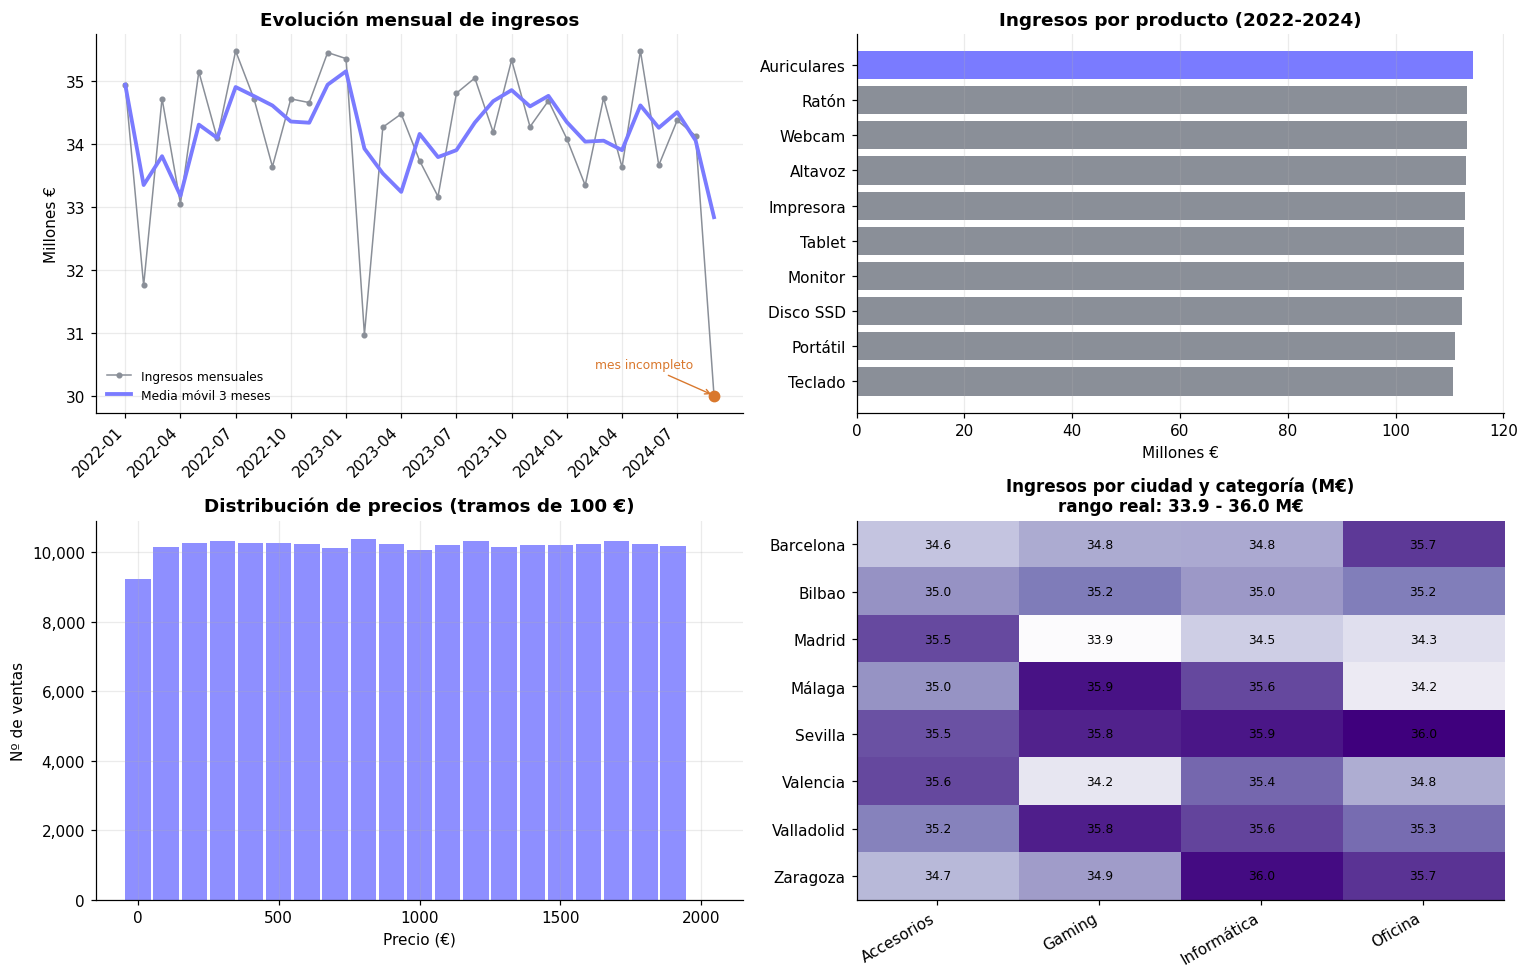

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- 1. Evolución mensual + media móvil ---
ax = axes[0, 0]
x = range(len(serie_pd))
ax.plot(x, serie_pd["Ingresos_MEUR"], color=GRIS, lw=1, marker="o", ms=3,
        label="Ingresos mensuales")
ax.plot(x, serie_pd["Media_movil_3m"], color=MORADO, lw=2.5, label="Media móvil 3 meses")

# El histórico termina el 27-09-2024: el último mes está incompleto y hay que señalarlo
ultimo = len(serie_pd) - 1
ax.scatter([ultimo], [serie_pd["Ingresos_MEUR"].iloc[-1]], color=NARANJA, s=45, zorder=5)
ax.annotate("mes incompleto", xy=(ultimo, serie_pd["Ingresos_MEUR"].iloc[-1]),
            xytext=(-78, 18), textcoords="offset points", fontsize=8, color=NARANJA,
            arrowprops=dict(arrowstyle="->", color=NARANJA, lw=0.9))

ax.set_title("Evolución mensual de ingresos")
ax.set_ylabel("Millones €")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels(serie_pd["AnioMes"][::3], rotation=45, ha="right")
ax.legend(frameon=False, fontsize=8)

# --- 2. Ingresos por producto ---
ax = axes[0, 1]
maximo = top_pd["Ingresos_MEUR"].max()
ax.barh(top_pd["Producto"], top_pd["Ingresos_MEUR"],
        color=[MORADO if v == maximo else GRIS for v in top_pd["Ingresos_MEUR"]])
ax.set_title("Ingresos por producto (2022-2024)")
ax.set_xlabel("Millones €")
ax.grid(axis="y", alpha=0)

# --- 3. Distribución de precios (tramos calculados en Spark) ---
ax = axes[1, 0]
ax.bar(bins_pd["tramo"], bins_pd["count"], width=90, color=MORADO, alpha=0.85)
ax.set_title("Distribución de precios (tramos de 100 €)")
ax.set_xlabel("Precio (€)")
ax.set_ylabel("Nº de ventas")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# --- 4. Mapa de calor Ciudad x Categoría ---
ax = axes[1, 1]
ax.imshow(heat_pd.values, cmap="Purples", aspect="auto")
ax.set_xticks(range(len(heat_pd.columns)))
ax.set_xticklabels(heat_pd.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heat_pd.index)))
ax.set_yticklabels(heat_pd.index)
for i in range(heat_pd.shape[0]):
    for j in range(heat_pd.shape[1]):
        ax.text(j, i, f"{heat_pd.values[i, j]:.1f}", ha="center", va="center", fontsize=8)
ax.set_title(f"Ingresos por ciudad y categoría (M€)\n"
             f"rango real: {heat_pd.values.min():.1f} - {heat_pd.values.max():.1f} M€",
             fontsize=11)
ax.grid(False)

plt.tight_layout()
plt.show()

### Lectura de los gráficos

**Los cuatro paneles cuentan la misma historia: no hay señal.** La media móvil es prácticamente horizontal, los diez productos ocupan una banda de apenas unos puntos porcentuales, la distribución de precios es **uniforme** (no la exponencial que produce cualquier catálogo real) y las 32 celdas del mapa de calor caben en un rango de **33,9 a 36,0 M€**.

Ese diagnóstico es el resultado honesto del análisis: **el dataset es sintético y está generado con distribuciones aleatorias**, y ningún hallazgo de negocio derivado de él sería real. Lo relevante aquí es el **pipeline**, no la conclusión comercial.

Pero los gráficos dejan además dos trampas que hay que saber ver, y que en un informe real costarían caras:

**1. El último punto de la serie no es una caída: es un mes incompleto.** El histórico termina el **27 de septiembre de 2024**, así que ese mes tiene tres días menos de ventas que el resto. La caída de ~34 a ~30 M€ es un artefacto del corte de los datos, no un desplome comercial. Es uno de los errores más frecuentes en cuadros de mando: **el periodo en curso siempre parece hundirse**. La solución en producción es excluir el periodo parcial o marcarlo explícitamente como incompleto.

**2. El mapa de calor exagera diferencias irrelevantes.** El gradiente de color reparte toda su intensidad entre el mínimo y el máximo de los datos — aquí, entre **33,9 y 36,0 M€**. Una diferencia real del **6 %** se pinta como el contraste entre blanco y morado intenso, y el ojo lee "Sevilla arrasa en Oficina" donde solo hay ruido. Por eso el título indica el rango real: **un mapa de calor sin escala declarada puede convertir cualquier variación en una historia**.

Sobre la técnica de visualización, dos cambios respecto al enfoque original:

- **El `scatter` de precio contra cantidad se ha eliminado.** 203.533 puntos sobre dos variables independientes producen un rectángulo negro sin información — además de traer todas las filas al driver. El mapa de calor agregado responde mejor a la misma pregunta.
- **El histograma se calcula en Spark**, agrupando por tramo de 100 € y trayendo ~20 filas, en lugar de traer 203.533 precios para que matplotlib los agrupe. **Este es el patrón que hay que interiorizar**: casi cualquier gráfico se puede expresar como una agregación, y esa agregación pertenece al motor distribuido.

---

## 15. MLlib: un pipeline, y una fuga de datos de manual

MLlib es la librería de ML distribuida de Spark. Su unidad de trabajo es el **`Pipeline`**, una secuencia de etapas (`Transformer` y `Estimator`) que se ajusta con `fit()` y se aplica con `transform()` — la misma abstracción que `sklearn.pipeline`, pero ejecutándose en paralelo sobre el clúster.

Empezamos con el planteamiento aparentemente obvio: **predecir el `Importe`** a partir de precio, cantidad, categoría y ciudad.

In [37]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

def entrenar(features, etiqueta, datos_train, datos_test):
    '''Monta, ajusta y evalúa un pipeline de regresión lineal.'''
    etapas, columnas = [], []
    tipos = dict(datos_train.dtypes)
    for c in features:
        if tipos.get(c) == "string":
            etapas.append(StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep"))
            etapas.append(OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe"))
            columnas.append(f"{c}_ohe")
        else:
            columnas.append(c)
    etapas.append(VectorAssembler(inputCols=columnas, outputCol="features"))
    etapas.append(LinearRegression(featuresCol="features", labelCol=etiqueta))

    modelo = Pipeline(stages=etapas).fit(datos_train)
    pred = modelo.transform(datos_test)
    evaluar = lambda m: RegressionEvaluator(labelCol=etiqueta, predictionCol="prediction",
                                            metricName=m).evaluate(pred)
    return {"R2": evaluar("r2"), "RMSE": evaluar("rmse"), "MAE": evaluar("mae")}

datos = df.select("Precio", "Cantidad", "Categoria", "Ciudad", "Mes", "Importe")
train, test = datos.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train.count():,} filas   Test: {test.count():,} filas\n")

m_a = entrenar(["Precio", "Cantidad", "Categoria", "Ciudad"], "Importe", train, test)
print("A) Importe ~ Precio + Cantidad + Categoria + Ciudad")
print(f"   R2 = {m_a['R2']:.4f}   RMSE = {m_a['RMSE']:,.2f} EUR   MAE = {m_a['MAE']:,.2f} EUR")

Train: 162,724 filas   Test: 40,809 filas



A) Importe ~ Precio + Cantidad + Categoria + Ciudad
   R2 = 0.8714   RMSE = 1,650.32 EUR   MAE = 1,245.95 EUR


### Antes de celebrar ese R²

Un R² de **0,87** en un primer modelo, sin tocar nada, debería disparar las alarmas y no la satisfacción. Y aquí el motivo es evidente en cuanto se mira cómo se construyó la variable objetivo:

```python
.withColumn("Importe", F.col("Precio") * F.col("Cantidad"))
```

**`Importe` no es un fenómeno a predecir: es una identidad aritmética entre dos de las variables predictoras.** Es una **fuga de datos** (*data leakage*) en su forma más pura. El modelo no aprende nada del negocio; intenta reconstruir una multiplicación.

El R² se queda en 0,87 y no en 1 solo porque una regresión **lineal** no puede representar el producto de dos variables. Si le damos la interacción explícitamente, el resultado lo demuestra.

In [38]:
# B) Añadimos el término de interacción Precio x Cantidad
train_b = train.withColumn("PrecioPorCantidad", F.col("Precio") * F.col("Cantidad"))
test_b  = test.withColumn("PrecioPorCantidad",  F.col("Precio") * F.col("Cantidad"))

m_b = entrenar(["Precio", "Cantidad", "PrecioPorCantidad"], "Importe", train_b, test_b)
print("B) Importe ~ Precio + Cantidad + (Precio x Cantidad)")
print(f"   R2 = {m_b['R2']:.4f}   RMSE = {m_b['RMSE']:,.2f} EUR   MAE = {m_b['MAE']:,.2f} EUR")

B) Importe ~ Precio + Cantidad + (Precio x Cantidad)
   R2 = 1.0000   RMSE = 0.00 EUR   MAE = 0.00 EUR


In [39]:
# C) Planteamiento honesto: predecir la CANTIDAD vendida, que no se deriva de nada
datos_c = df.select("Precio", "Cantidad", "Categoria", "Ciudad", "Mes")
train_c, test_c = datos_c.randomSplit([0.8, 0.2], seed=42)

m_c = entrenar(["Precio", "Categoria", "Ciudad", "Mes"], "Cantidad", train_c, test_c)
print("C) Cantidad ~ Precio + Categoria + Ciudad + Mes")
print(f"   R2 = {m_c['R2']:.4f}   RMSE = {m_c['RMSE']:.2f} uds   MAE = {m_c['MAE']:.2f} uds")

# Baseline: predecir siempre la media
media = train_c.select(F.avg("Cantidad")).first()[0]
rmse_base = test_c.select(F.sqrt(F.avg((F.col("Cantidad") - F.lit(media)) ** 2))).first()[0]
print(f"\n   Baseline (predecir siempre la media = {media:.2f}): RMSE = {rmse_base:.2f} uds")
print(f"   Correlación Precio-Cantidad: {df.stat.corr('Precio', 'Cantidad'):.4f}")

C) Cantidad ~ Precio + Categoria + Ciudad + Mes
   R2 = -0.0001   RMSE = 2.88 uds   MAE = 2.51 uds



   Baseline (predecir siempre la media = 5.51): RMSE = 2.88 uds


   Correlación Precio-Cantidad: 0.0007


### Interpretación: los tres modelos leídos juntos

| Modelo | Variable objetivo | R² | Qué significa realmente |
|---|---|---|---|
| **A** | `Importe` | **0,87** | Fuga de datos disimulada por la limitación del modelo lineal |
| **B** | `Importe` (+ interacción) | **1,0000** | RMSE = 0,00 €: **no es un modelo, es una fórmula** |
| **C** | `Cantidad` | **-0,0001** | Planteamiento honesto — y no hay nada que predecir |

**El modelo B es la prueba del delito.** Un R² de exactamente 1 y un error de exactamente 0 € no ocurren nunca en un problema real: significan que la variable objetivo se puede calcular a partir de las predictoras. Si esto apareciera en un proyecto de trabajo, la conclusión correcta no sería "tengo un modelo perfecto" sino **"he metido la respuesta entre las preguntas"**.

**El modelo C es el resultado honesto.** Con un R² **ligeramente negativo** —es decir, peor que la media— y un RMSE de **2,88 unidades**, exactamente el mismo que el de predecir siempre 5,51, el modelo no aporta absolutamente nada sobre el baseline más tonto posible. La correlación entre `Precio` y `Cantidad` es de **0,0007** — indistinguible de cero.

> **El hallazgo:** no hay señal predictiva en este dataset, y es exactamente lo que cabe esperar de datos generados con distribuciones aleatorias independientes. Reportarlo así es el resultado correcto; forzar un modelo hasta que dé un número presentable sería el error.

**Lo que sí queda validado** es la mecánica, que se aplica igual con datos reales: `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → estimador, todo encapsulado en un `Pipeline` que se ajusta una vez y se aplica a datos nuevos sin riesgo de usar transformaciones distintas en train y en test. El siguiente paso natural sería `CrossValidator` con `ParamGridBuilder` para ajustar hiperparámetros, y `GBTRegressor` en lugar de la regresión lineal — pero sobre un dataset sin señal, ninguno de los dos cambiaría el diagnóstico.

---

## 16. Chuleta pandas ↔ PySpark

| Operación | pandas | PySpark |
|---|---|---|
| Leer CSV | `pd.read_csv(ruta)` | `spark.read.csv(ruta, header=True, inferSchema=True)` |
| Ver esquema | `df.dtypes` | `df.printSchema()` |
| Primeras filas | `df.head()` | `df.show(5)` / `df.limit(5).toPandas()` |
| Nº de filas | `len(df)` | `df.count()` |
| Estadísticos | `df.describe()` | `df.summary()` |
| Filtrar | `df[df.Precio > 1000]` | `df.filter(F.col("Precio") > 1000)` |
| Nueva columna | `df["x"] = df.a * df.b` | `df.withColumn("x", F.col("a") * F.col("b"))` |
| Renombrar | `df.rename(columns={...})` | `df.withColumnRenamed("a", "b")` |
| Eliminar columna | `df.drop(columns=["a"])` | `df.drop("a")` |
| Agrupar | `df.groupby("a").agg({...})` | `df.groupBy("a").agg(F.sum("b"))` |
| Ordenar | `df.sort_values("a", ascending=False)` | `df.orderBy(F.desc("a"))` |
| Join | `pd.merge(a, b, on="k", how="left")` | `a.join(b, on="k", how="left")` |
| Nulos por columna | `df.isna().sum()` | `df.select([F.sum(F.col(c).isNull().cast("int")) for c in df.columns])` |
| Rellenar nulos | `df.fillna({...})` | `df.fillna({...})` |
| Duplicados | `df.drop_duplicates()` | `df.dropDuplicates()` |
| Condicional | `np.where(cond, a, b)` | `F.when(cond, a).otherwise(b)` |
| Ventana | `df.groupby("a")["b"].rank()` | `F.rank().over(Window.partitionBy("a").orderBy("b"))` |
| SQL | — | `df.createOrReplaceTempView("t"); spark.sql("...")` |
| Aplicar función | `df.a.apply(f)` | ⚠️ UDF: buscar antes el equivalente en `F` |
| Concatenar | `pd.concat([a, b])` | `a.union(b)` (por posición) / `a.unionByName(b)` |

### Los siete errores que hay que evitar

1. **No comprobar `printSchema()` tras leer** — el bug de la sección 2, y el más caro de todos.
2. **`from pyspark.sql.functions import sum, avg`** — sobrescribe las funciones nativas de Python. Usar siempre `import pyspark.sql.functions as F`.
3. **`toPandas()` o `collect()` sobre el DataFrame completo** — mata el driver. Agregar primero.
4. **Escribir una UDF sin buscar la función nativa** — un orden de magnitud más lento, medido en la sección 12.
5. **Dejar `spark.sql.shuffle.partitions` en 200 en local** — más tiempo coordinando que calculando.
6. **No cachear un DataFrame reutilizado** (o cachearlo todo) — diferencia medida en la sección 11.
7. **`Window.orderBy()` sin `partitionBy`** sobre datos en bruto — colapsa todo en una única partición.

### Adónde lleva esto

Este notebook cubre el núcleo de Spark. Los siguientes pasos naturales, en orden de utilidad para un perfil de Data Analytics / BI:

- **Delta Lake** — Parquet con transacciones ACID, *time travel* y `MERGE`. Es el formato nativo de Databricks y Fabric, y lo que permite hacer *upserts* sobre un lakehouse.
- **Structured Streaming** — el mismo código de DataFrames aplicado a datos que llegan en continuo, con la misma API.
- **Databricks / Microsoft Fabric** — el clúster gestionado. En Fabric, los notebooks del Lakehouse ejecutan exactamente este PySpark, y el resultado alimenta el modelo semántico de Power BI. Todo lo de aquí se traslada sin cambiar una línea salvo la ruta y el `.master()`.

In [40]:
# Liberar la caché y cerrar la sesión: los executors devuelven memoria y CPU
df.unpersist()
spark.stop()
print("Sesión de Spark cerrada.")

Sesión de Spark cerrada.


---

## Conclusión

> **El hallazgo:** el dataset no contiene ninguna señal — ingresos uniformes entre las 4 categorías y las 8 ciudades, variación mensual indistinguible del ruido, correlación precio-cantidad de **0,0007** y un modelo predictivo con **R² = 0**. Es un generador de datos aleatorios, y el análisis honesto termina ahí. Lo que sí queda validado es el pipeline, que era el objetivo del ejercicio.

**Lo que se corrigió respecto a la primera versión del ejercicio:**

1. **El typo `inferShema`** convertía las 7 columnas en texto y falseaba `describe()`: el precio máximo real es **2.000 €**, no 999,99 €; la cantidad máxima es **10**, no 9; el `IdVenta` máximo es **203.533**, no 99.999.
2. **`from pyspark.sql.functions import sum, avg`** sobrescribía las funciones nativas de Python — sustituido por `import ... as F`.
3. **Dos `toPandas()` sobre el DataFrame completo** traían 203.533 filas al driver y releían el fichero dos veces — sustituidos por agregación previa en Spark.
4. **El `scatter` de 203.533 puntos** no era legible ni informativo — sustituido por agregaciones que responden a la misma pregunta.
5. **`spark.sql.shuffle.partitions` en su valor por defecto (200)** para un dataset local pequeño.

**Lo que se midió, en vez de afirmarse:** el coste de una UDF frente a las funciones nativas, el ahorro del esquema explícito frente a `inferSchema`, el efecto de `cache()` sobre una carga repetida y la compresión de Parquet frente a CSV.

**Y dos mediciones que salieron en contra de lo esperado**, que es justo por lo que merece la pena medir: `approx_count_distinct` resultó **más lento** que el conteo exacto (sección 6) y `pandas_udf` **no mejoró** a la UDF clásica (sección 12). Ambas son optimizaciones reales, pero a una escala que este dataset no alcanza. Darlas por buenas sin comprobarlas habría sido repetir una recomendación de manual sin sustento.

**Las tres ideas que se trasladan a cualquier proyecto con Spark:**

1. **El esquema es un contrato, no un detalle.** La mayoría de los errores silenciosos en pipelines de datos empiezan en la lectura.
2. **Contar los `Exchange` de un plan estima su coste** mejor que cualquier intuición. `explain()` debería ser tan habitual como `show()`.
3. **Todo lo que se pueda expresar como agregación pertenece al motor distribuido**, y solo el resultado agregado debe llegar al driver — sea para un gráfico, un informe o un modelo.